In [56]:
%pip install noise numpy matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from noise import pnoise3
import math
import hashlib

# Color mapping dictionary for visualization
ROAD_TYPES_MAP = {
    0: {
        'color': [0.0, 0.4, 0.0], # Dark green for terrain
        'radius': 0
    },
    1: {
        'color': [0.6, 0.6, 0.6], # Gray for highways
        'radius': 6
    },     
    2: {
        'color': [0.8, 0.8, 0.6], # Light beige for roads
        'radius': 4
    },     
    3: {
        'color': [0.4, 0.4, 0.4], # Dark gray for streets
        'radius': 2
     },
    4: {
        'color': [0.6, 0.3, 0.1], # Brown for buildings
        'radius': 0
    },
}

def apply_color_map(array, color_map):
    """
    Apply color mapping to a 2D array of integers.
    
    Args:
        array: 2D numpy array with integer values
        color_map: Dictionary mapping integers to RGB colors (as lists/tuples)
    
    Returns:
        3D numpy array with shape (height, width, 3) for RGB visualization
    """
    height, width = array.shape
    # Initialize with dark green as default color (for terrain/background)
    colored = np.full((height, width, 3), [0.0, 0.4, 0.0])
    
    for value, properties in color_map.items():
        mask = array == value
        colored[mask] = properties['color']
    
    return colored

# Utility: draw filled disk into canvas
def draw_disk(canvas, x, y, radius=2):
    h, w = canvas.shape
    xi = int(round(x))
    yi = int(round(y))
    rx = range(max(0, xi-radius), min(w, xi+radius+1))
    ry = range(max(0, yi-radius), min(h, yi+radius+1))
    rr = radius*radius
    for nx in rx:
        for ny in ry:
            dx = nx - x
            dy = ny - y
            if dx*dx + dy*dy <= rr:
                canvas[ny, nx] = 1  # Changed from 255 to 1

# Quantized angle sampling using Perlin (noise.pnoise3)
def quantized_angle(x, y, scale, grid_angles, noise_strength, seed):
    # pnoise3 returns in [-1,1] for typical usage; keep it deterministic via seed offset
    val = pnoise3(x*scale, y*scale, seed) * noise_strength
    # clamp to [-1,1] then map to [0,1] range for more stable rounding
    val = max(-1.0, min(1.0, val))
    base = round(val * grid_angles) * (2.0 * math.pi / grid_angles)
    return base

## Chunk-aware generation

We implement a chunk-aware generator which: uses global/world coordinates for Perlin sampling, places deterministic worm starts via a spatial hash, and generates with padding so roads crossing borders appear in adjacent chunks.

In [58]:
def spatial_hash(seed, i, j, k=0):
    # deterministic float in [0,1) from integer inputs
    m = hashlib.sha256()
    m.update(f'{seed}:{i}:{j}:{k}'.encode('utf-8'))
    h = m.digest()
    # take first 8 bytes as uint64
    v = int.from_bytes(h[:8], 'little')
    return (v & ((1<<53)-1)) / float(1<<53)

# Utility: draw filled disk with specific value into canvas
def draw_disk(canvas, x, y, road_type):
    h, w = canvas.shape
    radius = ROAD_TYPES_MAP[road_type]['radius']
    value = road_type
    xi = int(round(x))
    yi = int(round(y))
    rx = range(max(0, xi-radius), min(w, xi+radius+1))
    ry = range(max(0, yi-radius), min(h, yi+radius+1))
    rr = radius*radius
    for nx in rx:
        for ny in ry:
            dx = nx - x
            dy = ny - y
            if dx*dx + dy*dy <= rr:
                canvas[ny, nx] = value

In [59]:
def generate_highways(canvas, gx, gy, world_offset_x, world_offset_y, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed):
    """
    Generate highways on the canvas.
    
    Args:
        canvas: The 2D array to draw on (values 0 for terrain)
        gx, gy: Grid cell coordinates for calculating start positions
        world_offset_x, world_offset_y: World offset to convert to local canvas coordinates
        worm_length: Number of steps the worm takes
        step_size: Distance moved per step
        perlin_scale: Scale factor for Perlin noise sampling
        grid_angles: Number of discrete angle directions
        noise_strength: Strength of the noise influence
        seed: Random seed for deterministic generation
    
    Returns:
        canvas: The modified canvas with highways marked as 1
    """
    # Calculate cell spacing (same logic as in generate_chunk)
    chunk_size = canvas.shape[0]  # Assuming square canvas
    padding = (chunk_size - 256) // 2  # Reverse calculate padding
    cell_spacing = max(16, padding // 2)
    road_type = 1  # Highway type
    
    # Calculate start_x and start_y from gx, gy (same logic as in generate_chunk)
    u = spatial_hash(seed, gx, gy, 0)
    v = spatial_hash(seed, gx, gy, 1)
    start_x = gx * cell_spacing + u * cell_spacing
    start_y = gy * cell_spacing + v * cell_spacing
    
    # Draw the highway worm using the new function with value 1
    x, y = start_x, start_y
    canvas_height, canvas_width = canvas.shape
    
    for j in range(worm_length):
        # Convert world coordinates to local canvas coordinates
        lx = x - world_offset_x
        ly = y - world_offset_y
        
        # Only draw if position is within canvas bounds
        if 0 <= lx < canvas_width and 0 <= ly < canvas_height:
            draw_disk(canvas, lx, ly, road_type=road_type)
        
        # Get direction from Perlin noise using world coordinates
        angle = quantized_angle(x, y, perlin_scale, grid_angles, noise_strength, seed)
        
        # Move to next position
        x += math.cos(angle) * step_size
        y += math.sin(angle) * step_size
    
    return canvas

In [60]:
def generate_roads(canvas, gx, gy, world_offset_x, world_offset_y, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed):
    """
    Generate roads on the canvas.
    
    Args:
        canvas: The 2D array to draw on (values 0 for terrain, 1 for highways)
        gx, gy: Grid cell coordinates for calculating start positions
        world_offset_x, world_offset_y: World offset to convert to local canvas coordinates
        worm_length: Number of steps the worm takes
        step_size: Distance moved per step
        perlin_scale: Scale factor for Perlin noise sampling
        grid_angles: Number of discrete angle directions
        noise_strength: Strength of the noise influence
        seed: Random seed for deterministic generation
    
    Returns:
        canvas: The modified canvas with roads marked as 2
    """
    # Calculate cell spacing (same logic as in generate_chunk)
    chunk_size = canvas.shape[0]  # Assuming square canvas
    padding = (chunk_size - 256) // 2  # Reverse calculate padding
    cell_spacing = max(16, padding // 2)
    road_type = 2
    # Calculate start_x and start_y from gx, gy (same logic as in generate_chunk)
    u = spatial_hash(seed, gx, gy, 0)
    v = spatial_hash(seed, gx, gy, 1)
    start_x = gx * cell_spacing + u * cell_spacing
    start_y = gy * cell_spacing + v * cell_spacing
    
    # Draw the road worm using the new function with value 2
    x, y = start_x, start_y
    canvas_height, canvas_width = canvas.shape
    
    for j in range(worm_length):
        # Convert world coordinates to local canvas coordinates
        lx = x - world_offset_x
        ly = y - world_offset_y
        
        # Only draw if position is within canvas bounds
        if 0 <= lx < canvas_width and 0 <= ly < canvas_height:
            draw_disk(canvas, lx, ly, road_type=road_type)
        
        # Get direction from Perlin noise using world coordinates
        angle = quantized_angle(x, y, perlin_scale, grid_angles, noise_strength, seed)
        
        # Move to next position
        x += math.cos(angle) * step_size
        y += math.sin(angle) * step_size
    
    return canvas

In [61]:
def generate_streets(canvas, gx, gy, world_offset_x, world_offset_y, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed):
    """
    Generate streets on the canvas.
    
    Args:
        canvas: The 2D array to draw on (values 0 for terrain, 1 for highways, 2 for roads)
        gx, gy: Grid cell coordinates for calculating start positions
        world_offset_x, world_offset_y: World offset to convert to local canvas coordinates
        worm_length: Number of steps the worm takes
        step_size: Distance moved per step
        perlin_scale: Scale factor for Perlin noise sampling
        grid_angles: Number of discrete angle directions
        noise_strength: Strength of the noise influence
        seed: Random seed for deterministic generation
    
    Returns:
        canvas: The modified canvas with streets marked as 3
    """
    canvas_height, canvas_width = canvas.shape
    road_type = 3
    
    # Find all road pixels (value 2) to start streets from their edges
    road_pixels = np.where(canvas == 2)
    if len(road_pixels[0]) == 0:
        print("No roads to branch from")
        return canvas  # No roads to branch from
    
    # Increase the number of street starts - more aggressive street generation
    num_street_starts = min(len(road_pixels[0]) // 5, 200)  # Changed from //10 to //5, max increased to 50
    
    for i in range(num_street_starts):
        # Use spatial hash to deterministically select road pixels
        hash_val = spatial_hash(seed + 1000, gx, gy, i)
        road_idx = int(hash_val * len(road_pixels[0]))
        
        start_ly = road_pixels[0][road_idx]
        start_lx = road_pixels[1][road_idx]
        
        # Convert to world coordinates
        start_x = start_lx + world_offset_x
        start_y = start_ly + world_offset_y
        
        # Find the direction of the road at this point by checking neighboring road pixels
        road_direction = get_road_direction(canvas, start_lx, start_ly)
        
        # Generate perpendicular directions based on grid_angles
        perpendicular_angles = get_perpendicular_angles(road_direction, grid_angles)
        
        # Choose one of the perpendicular directions
        direction_hash = spatial_hash(seed + 2000, gx, gy, i)
        chosen_angle = perpendicular_angles[int(direction_hash * len(perpendicular_angles))]
        
        # Generate the street worm with longer length - convert to int
        street_length = int(worm_length * 2 // 3)  # Changed from //1.5 to *2//3 and convert to int
        generate_street_worm(canvas, start_x, start_y, world_offset_x, world_offset_y, 
                           street_length, step_size, chosen_angle, perlin_scale, 
                           grid_angles, noise_strength, seed + i, road_type)  # Increased noise from 0.5 to 0.7
    
    return canvas

def get_road_direction(canvas, x, y):
    """
    Estimate the direction of a road at a given point by checking neighboring pixels.
    
    Returns:
        Average angle of the road direction in radians
    """
    directions = []
    
    # Check 8 neighboring directions
    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            if dx == 0 and dy == 0:
                continue
            
            nx, ny = x + dx, y + dy
            if 0 <= nx < canvas.shape[1] and 0 <= ny < canvas.shape[0]:
                if canvas[ny, nx] == 2:  # Road pixel
                    angle = math.atan2(dy, dx)
                    directions.append(angle)
    
    if not directions:
        return 0  # Default direction if no neighbors found
    
    # Average the angles (handling circular nature)
    avg_x = sum(math.cos(angle) for angle in directions) / len(directions)
    avg_y = sum(math.sin(angle) for angle in directions) / len(directions)
    return math.atan2(avg_y, avg_x)

def get_perpendicular_angles(road_angle, grid_angles):
    """
    Get perpendicular angles based on the road direction and grid_angles.
    
    Args:
        road_angle: The estimated direction of the road in radians
        grid_angles: Number of discrete angle directions
    
    Returns:
        List of perpendicular angles
    """
    # Calculate the step size for grid angles
    angle_step = 2 * math.pi / grid_angles
    
    # Find perpendicular directions (90 degrees from road direction)
    perp1 = road_angle + math.pi / 2
    perp2 = road_angle - math.pi / 2
    
    # Quantize to grid angles
    perp1_quantized = round(perp1 / angle_step) * angle_step
    perp2_quantized = round(perp2 / angle_step) * angle_step
    
    return [perp1_quantized, perp2_quantized]

def generate_street_worm(canvas, start_x, start_y, world_offset_x, world_offset_y, 
                        worm_length, step_size, initial_angle, perlin_scale, 
                        grid_angles, noise_strength, seed, road_type):
    """
    Generate a single street worm with constraints.
    
    Args:
        canvas: The 2D array to draw on
        start_x, start_y: Starting position in world coordinates
        world_offset_x, world_offset_y: World offset to convert to local canvas coordinates
        worm_length: Number of steps the worm takes (must be integer)
        step_size: Distance moved per step
        initial_angle: Initial direction angle in radians
        perlin_scale: Scale factor for Perlin noise sampling
        grid_angles: Number of discrete angle directions
        noise_strength: Strength of the noise influence
        seed: Random seed for deterministic generation
        road_type: The value to set for streets (3)
    """
    x, y = start_x, start_y
    canvas_height, canvas_width = canvas.shape
    current_angle = initial_angle
    
    # Reduced minimum distance before allowing turns for more organic streets
    min_straight_distance = 2  # Changed from 3 to 2
    steps_since_turn = 0
    
    for j in range(worm_length):
        # Convert world coordinates to local canvas coordinates
        lx = x - world_offset_x
        ly = y - world_offset_y

        # Calculate next position
        next_x = x + math.cos(current_angle) * step_size
        next_y = y + math.sin(current_angle) * step_size
        
        # Convert next position to local canvas coordinates
        next_lx = next_x - world_offset_x
        next_ly = next_y - world_offset_y
        
        # Check if next position will be out of bounds
        if not (0 <= next_lx < canvas_width and 0 <= next_ly < canvas_height):
            break
            
        # Check if next position will hit a road (stop the street before hitting)
        if canvas[int(next_ly), int(next_lx)] == 2:
            break
            
        # Only draw if position is within canvas bounds and not on a road
        if 0 <= lx < canvas_width and 0 <= ly < canvas_height:
            if canvas[int(ly), int(lx)] == 0:  # Only draw on terrain
                draw_disk(canvas, lx, ly, road_type=road_type)
        
        # Update angle with noise, but less frequently than roads
        if steps_since_turn >= min_straight_distance:
            # Allow turns with reduced noise influence
            noise_angle = quantized_angle(x, y, perlin_scale * 2, grid_angles, noise_strength, seed)
            
            # Reduced threshold for turning to allow more turns
            angle_diff = abs(noise_angle - current_angle)
            if angle_diff > math.pi / (grid_angles * 3):  # Changed from *2 to *3 for easier turning
                current_angle = noise_angle
                steps_since_turn = 0
        
        # Move to next position
        x = next_x
        y = next_y
        steps_since_turn += 1

In [62]:
def generate_buildings(canvas, gx, gy, world_offset_x, world_offset_y, seed, density=1.0):
    """
    Generate buildings by populating the grid, avoiding roads and other buildings.
    Buildings can be polygonal shapes created using cells.
    Buildings are always placed adjacent to roads for accessibility.
    
    Args:
        canvas: The 2D array with road data (0=terrain, 1=highways, 2=roads, 3=streets)
        gx, gy: Grid cell coordinates
        world_offset_x, world_offset_y: World offset to convert to local canvas coordinates
        seed: Random seed for deterministic generation
        density: Building density multiplier (default 1.0, higher = more buildings)
    
    Returns:
        canvas: The modified canvas with buildings marked as 4
    """
    canvas_height, canvas_width = canvas.shape
    
    # Find all road and highway pixels to place buildings near them
    road_pixels = np.where((canvas == 1) | (canvas == 2) | (canvas == 3))
    if len(road_pixels[0]) == 0:
        return canvas
    
    # Determine number of building attempts based on grid cell and density
    base_attempts = int(spatial_hash(seed + 3000, gx, gy, 0) * 50) + 20
    num_attempts = int(base_attempts * density)
    
    for i in range(num_attempts):
        # Randomly select a road pixel as the access point
        hash_val = spatial_hash(seed + 3000, gx, gy, i)
        road_idx = int(hash_val * len(road_pixels[0]))
        
        road_ly = road_pixels[0][road_idx]
        road_lx = road_pixels[1][road_idx]
        
        # Determine road type at this location for building sizing
        road_type = canvas[road_ly, road_lx]
        
        # Building size depends on road type
        if road_type == 1:  # Highway - larger buildings
            min_size, max_size = 15, 30
        elif road_type == 2:  # Road - medium buildings
            min_size, max_size = 10, 20
        else:  # Street - smaller buildings
            min_size, max_size = 6, 12
        
        # Generate building size deterministically
        size_hash = spatial_hash(seed + 4000, gx, gy, i)
        building_width = min_size + int(size_hash * (max_size - min_size))
        
        height_hash = spatial_hash(seed + 4100, gx, gy, i)
        building_height = min_size + int(height_hash * (max_size - min_size))
        
        # Determine which side of the road to place building (perpendicular offset)
        # This ensures building is adjacent to the road
        side_hash = spatial_hash(seed + 5000, gx, gy, i)
        
        # Try 4 cardinal directions from the road pixel to place building
        directions = [
            (0, -1),   # North (place building above road)
            (0, 1),    # South (place building below road)
            (-1, 0),   # West (place building left of road)
            (1, 0)     # East (place building right of road)
        ]
        
        direction_idx = int(side_hash * len(directions))
        dx, dy = directions[direction_idx]
        
        # Place building immediately adjacent to road (with 1 pixel gap for the road edge)
        gap = 1  # Minimum gap from road
        center_lx = road_lx + dx * (gap + building_width // 2)
        center_ly = road_ly + dy * (gap + building_height // 2)
        
        # Determine building shape type
        shape_hash = spatial_hash(seed + 6000, gx, gy, i)
        
        # Generate polygonal building shape
        if shape_hash < 0.4:  # 40% rectangles
            building_shape = generate_rectangle_shape(building_width, building_height)
        elif shape_hash < 0.7:  # 30% L-shapes
            building_shape = generate_l_shape(building_width, building_height, seed + i)
        elif shape_hash < 0.85:  # 15% T-shapes
            building_shape = generate_t_shape(building_width, building_height, seed + i)
        else:  # 15% irregular polygons
            building_shape = generate_irregular_polygon(building_width, building_height, seed + i)
        
        # Try to place the building
        if try_place_building(canvas, center_lx, center_ly, building_shape):
            pass  # Building placed successfully
    
    return canvas

def generate_rectangle_shape(width, height):
    """Generate a simple rectangular building shape."""
    return [(0, 0), (width, 0), (width, height), (0, height)]

def generate_l_shape(width, height, seed):
    """Generate an L-shaped building."""
    # Create L-shape with random proportions
    h1 = spatial_hash(seed, 0, 0, 0)
    h2 = spatial_hash(seed, 0, 0, 1)
    
    w1 = int(width * (0.4 + h1 * 0.3))  # 40-70% of width
    h1 = int(height * (0.4 + h2 * 0.3))  # 40-70% of height
    
    return [
        (0, 0), (w1, 0), (w1, h1), 
        (width, h1), (width, height), (0, height)
    ]

def generate_t_shape(width, height, seed):
    """Generate a T-shaped building."""
    h1 = spatial_hash(seed, 0, 0, 0)
    h2 = spatial_hash(seed, 0, 0, 1)
    
    w_center = int(width * (0.3 + h1 * 0.2))  # Center stem width
    h_top = int(height * (0.3 + h2 * 0.2))     # Top bar height
    
    x_offset = (width - w_center) // 2
    
    return [
        (0, 0), (width, 0), (width, h_top),
        (x_offset + w_center, h_top), (x_offset + w_center, height),
        (x_offset, height), (x_offset, h_top), (0, h_top)
    ]

def generate_irregular_polygon(width, height, seed):
    """Generate an irregular polygonal building."""
    # Create 5-7 sided polygon
    num_sides = 5 + int(spatial_hash(seed, 0, 0, 0) * 3)
    
    # Generate points around a center
    points = []
    for i in range(num_sides):
        angle = (2 * math.pi * i) / num_sides
        # Add some randomness to radius
        r_hash = spatial_hash(seed, i, 0, 0)
        radius_x = (width // 2) * (0.6 + r_hash * 0.4)
        radius_y = (height // 2) * (0.6 + r_hash * 0.4)
        
        x = int((width // 2) + radius_x * math.cos(angle))
        y = int((height // 2) + radius_y * math.sin(angle))
        points.append((x, y))
    
    return points

def try_place_building(canvas, center_x, center_y, shape_points):
    """
    Try to place a polygonal building on the canvas.
    
    Args:
        canvas: The canvas to draw on
        center_x, center_y: Center position for the building
        shape_points: List of (x, y) points defining the building polygon (relative coordinates)
    
    Returns:
        bool: True if building was placed, False otherwise
    """
    canvas_height, canvas_width = canvas.shape
    
    # Translate shape points to world coordinates (centered on center position)
    half_w = (max(p[0] for p in shape_points) - min(p[0] for p in shape_points)) // 2
    half_h = (max(p[1] for p in shape_points) - min(p[1] for p in shape_points)) // 2
    
    translated_points = [(center_x - half_w + x, 
                          center_y - half_h + y) 
                         for x, y in shape_points]
    
    # Find bounding box
    min_x = max(0, int(min(p[0] for p in translated_points)))
    max_x = min(canvas_width, int(max(p[0] for p in translated_points)) + 1)
    min_y = max(0, int(min(p[1] for p in translated_points)))
    max_y = min(canvas_height, int(max(p[1] for p in translated_points)) + 1)
    
    if min_x >= max_x or min_y >= max_y:
        return False
    
    # Collect all points that would be part of the building
    building_pixels = []
    for y in range(min_y, max_y):
        for x in range(min_x, max_x):
            if point_in_polygon((x, y), translated_points):
                building_pixels.append((x, y))
    
    if len(building_pixels) == 0:
        return False
    
    # Check if any building pixel intersects with roads or other buildings
    for y, x in building_pixels:
        if canvas[y, x] != 0:
            return False
    
    # Check that at least one pixel is adjacent to a road (for accessibility)
    has_road_access = False
    for y, x in building_pixels:
        # Check 4-connected neighbors for road access
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ny, nx = y + dy, x + dx
            if 0 <= ny < canvas_height and 0 <= nx < canvas_width:
                if canvas[ny, nx] in [1, 2, 3]:  # Adjacent to highway, road, or street
                    has_road_access = True
                    break
        if has_road_access:
            break
    
    if not has_road_access:
        return False
    
    # Place the building
    for y, x in building_pixels:
        canvas[y, x] = 4
    
    return True

def point_in_polygon(point, polygon):
    """
    Check if a point is inside a polygon using ray casting algorithm.
    """
    x, y = point
    n = len(polygon)
    inside = False
    
    p1x, p1y = polygon[0]
    for i in range(1, n + 1):
        p2x, p2y = polygon[i % n]
        if y > min(p1y, p2y):
            if y <= max(p1y, p2y):
                if x <= max(p1x, p2x):
                    if p1y != p2y:
                        xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                    if p1x == p2x or x <= xinters:
                        inside = not inside
        p1x, p1y = p2x, p2y
    
    return inside

In [63]:
def generate_chunk(chunk_x, chunk_y, chunk_size=256, padding=64, num_highways=2, num_roads=200, num_streets=100, worm_length=800, step_size=1.0, perlin_scale=0.01, seed=2, grid_angles=4, noise_strength=1.0, road_width=3, building_density=1.0):
    # world region to generate (with padding)
    wx = chunk_x * chunk_size - padding
    wy = chunk_y * chunk_size - padding
    size = chunk_size + 2*padding
    canvas = np.zeros((size, size), dtype=np.uint8)  # Canvas with 0s (terrain)
    
    # Choose a fixed global grid spacing (cells that hold deterministic start offsets)
    cell_spacing = max(16, padding // 2)
    gx_min = math.floor(wx / cell_spacing)
    gx_max = math.floor((wx + size) / cell_spacing)
    gy_min = math.floor(wy / cell_spacing)
    gy_max = math.floor((wy + size) / cell_spacing)
    
    count = 0
    for gx in range(gx_min, gx_max + 1):
        for gy in range(gy_min, gy_max + 1):
            if count >= num_highways:
                break
            
            # Stage 1: Generate highways (value 1)
            canvas = generate_highways(canvas, gx, gy, wx, wy, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed)
            count += 1
    
    count = 0
    for gx in range(gx_min, gx_max + 1):
        for gy in range(gy_min, gy_max + 1):
            if count >= num_roads:
                break

            # Stage 2: Generate roads (value 2)
            canvas = generate_roads(canvas, gx, gy, wx, wy, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed)
            count += 1

    count = 0
    for gx in range(gx_min, gx_max + 1):
        for gy in range(gy_min, gy_max + 1):
            if count >= num_streets:
                break

            # Stage 3: Generate streets (value 3)
            canvas = generate_streets(canvas, gx, gy, wx, wy, worm_length, step_size, perlin_scale, grid_angles, noise_strength, seed)
            count += 1
    
    # Stage 4: Generate buildings (value 4) - directly modifies canvas
    for gx in range(gx_min, gx_max + 1):
        for gy in range(gy_min, gy_max + 1):
            canvas = generate_buildings(canvas, gx, gy, wx, wy, seed, density=building_density)
    
    # crop to chunk region
    sx = padding
    sy = padding
    cropped = canvas[sy:sy+chunk_size, sx:sx+chunk_size].copy()
    return cropped

Stitched array shape: (768, 768)
Unique values in array: [0 1 2 3 4]
Number of terrain pixels (0s): 424122
Number of highway pixels (1s): 5670
Number of road pixels (2s): 78541
Number of street pixels (3s): 26142
Number of building pixels (4s): 55349


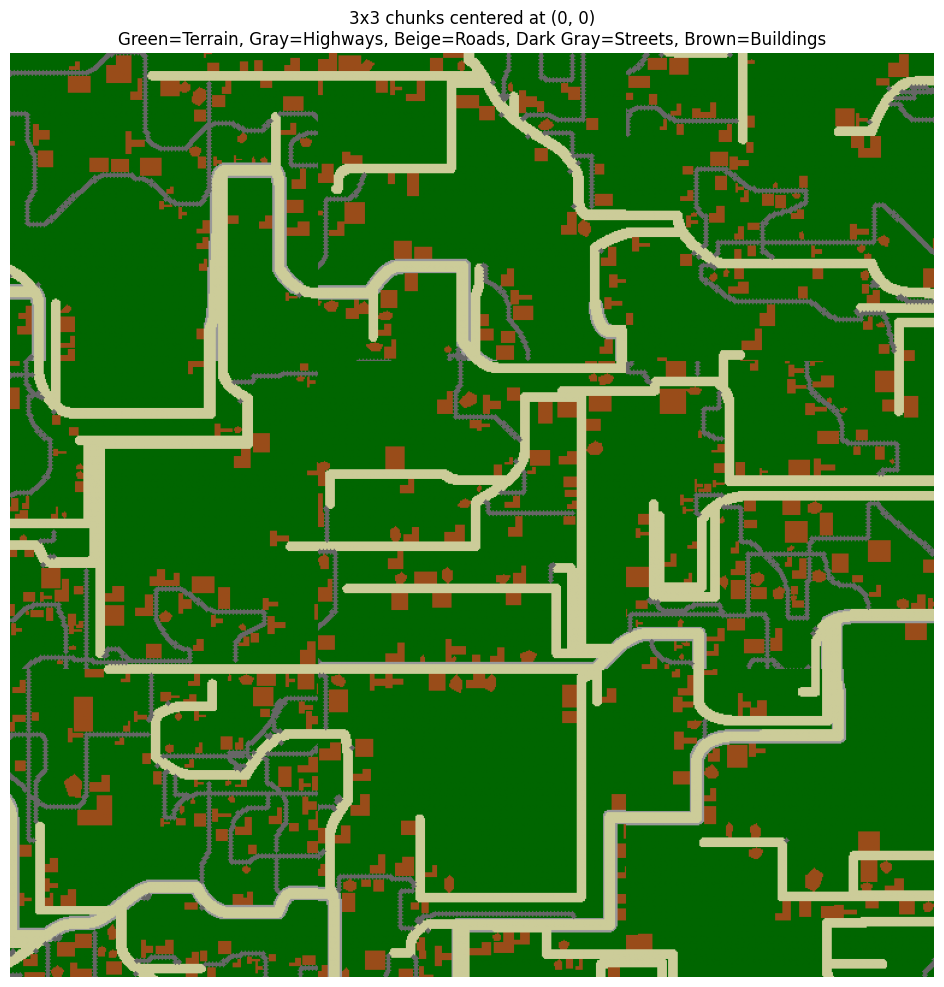

In [65]:
# Generate a square grid of chunks centered on a given chunk coordinate
# Specify the center chunk coordinates (world chunk indices) and a radius (half-size).
# radius=2 -> 5x5 grid
center_x, center_y = 0, 0  # change these to any world chunk coordinates
radius = 1
rows = []
for gy in range(center_y - radius, center_y + radius + 1):
    row_chunks = []
    for gx in range(center_x - radius, center_x + radius + 1):
        # generate each chunk at global chunk coordinates (gx, gy)
        # The new refactored generate_chunk handles highways, roads, streets, and buildings
        c = generate_chunk(
            gx, gy,
            chunk_size=256,
            padding=256,
            num_highways=2,
            num_roads=200,
            num_streets=300,  # Increased from 100 to 300 for more streets
            worm_length=1000,
            seed=42,
            grid_angles=4,
            perlin_scale=0.01,
            road_width=5,
            building_density=15.0  # Adjust density: 1.0 = default, 2.0 = double density, 0.5 = half density
        )
        
        row_chunks.append(c)
    # concatenate chunks horizontally for this row
    rows.append(np.hstack(row_chunks))
# stack all rows vertically to form the full grid
stitched = np.vstack(rows)

# Print some info about the generated data
print(f"Stitched array shape: {stitched.shape}")
print(f"Unique values in array: {np.unique(stitched)}")
print(f"Number of terrain pixels (0s): {np.sum(stitched == 0)}")
print(f"Number of highway pixels (1s): {np.sum(stitched == 1)}")
print(f"Number of road pixels (2s): {np.sum(stitched == 2)}")
print(f"Number of street pixels (3s): {np.sum(stitched == 3)}")
print(f"Number of building pixels (4s): {np.sum(stitched == 4)}")

# Apply color mapping for visualization
colored_image = apply_color_map(stitched, ROAD_TYPES_MAP)

plt.figure(figsize=(12,12))
plt.imshow(colored_image, origin='lower')
plt.title(f'{(2*radius+1)}x{(2*radius+1)} chunks centered at ({center_x}, {center_y})\nGreen=Terrain, Gray=Highways, Beige=Roads, Dark Gray=Streets, Brown=Buildings')
plt.axis('off')
plt.show()

Notes:
- This implementation uses global-coordinate Perlin sampling and deterministic worm starts via `spatial_hash`.
- Padding allows worms that start outside a chunk to paint into it, avoiding visible seams.
- Parameters (padding, num_worms, worm_length) trade memory and quality; tune per your needs.